# Atividade Prática: Processamento Digital de Sinais
**Objetivos da atividade:**
1. Utilizar pacotes do Python para representar e manipular sinais discretos.
2. Implementar uma função para calcular a convolução discreta.
3. Analisar a complexidade computacional.
4. Testar aceleração de código com Numba e CuPy.

---
## Entrega exigida:
- Relatório em PDF (Introdução, Desenvolvimento, Resultados e Conclusão).
- Repositório no GitHub com este código.

## 1. Representação e Manipulação de Sinais Discretos
No Python, utilizamos principalmente o `numpy` para representar os sinais como vetores (arrays) e o `matplotlib` para visualização, geralmente utilizando a função `stem` para enfatizar o caráter discreto (amostrado) do sinal.

In [5]:
pip install cupy-cuda11x

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.7/99.7 MB 7.6 MB/s eta 0:00:00:00:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import jit

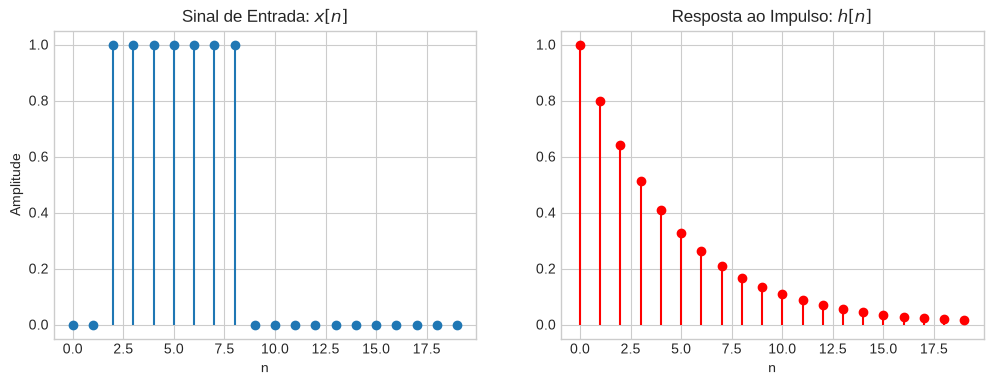

In [5]:

# Configuração de estilo para os gráficos
plt.style.use('seaborn-v0_8-whitegrid')

# Gerando dois sinais discretos de exemplo
n = np.arange(0, 20) # Vetor de tempo discreto

# Sinal x[n]: Pulso retangular
x = np.where((n >= 2) & (n <= 8), 1.0, 0.0)

# Sinal h[n]: Resposta ao impulso (ex: decaimento exponencial)
h = np.where(n >= 0, (0.8)**n, 0.0)

# Plotando os sinais
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.stem(n, x, basefmt=" ")
plt.title('Sinal de Entrada: $x[n]$')
plt.xlabel('n')
plt.ylabel('Amplitude')

plt.subplot(1, 2, 2)
plt.stem(n, h, linefmt='r-', markerfmt='ro', basefmt=" ")
plt.title('Resposta ao Impulso: $h[n]$')
plt.xlabel('n')
plt.show()

## 2. Implementação da Convolução Discreta
A convolução discreta unidimensional entre dois sinais $x[n]$ e $h[n]$ é dada pela soma:

$$ y[n] = x[n] * h[n] = \sum_{k=-\infty}^{\infty} x[k]h[n-k] $$

Para sinais de tamanho finito $N_x$ e $N_h$, o tamanho do sinal resultante será $N_y = N_x + N_h - 1$.

Erro máximo entre a implementação manual e NumPy: 1.1102230246251565e-16


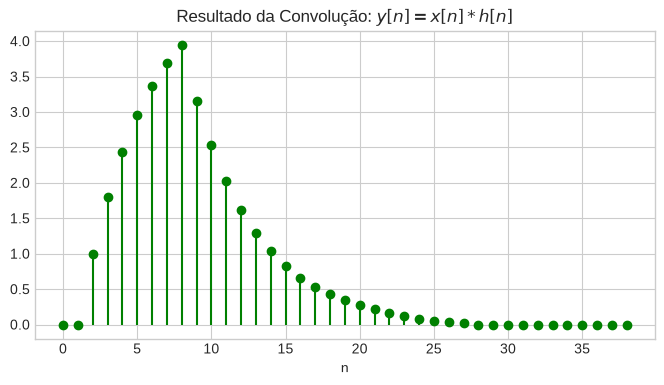

In [6]:
def minha_convolucao(x, h):
    """
    Calcula a convolução discreta linear entre dois sinais 1D usando loops aninhados.
    """
    Nx = len(x)
    Nh = len(h)
    Ny = Nx + Nh - 1
    
    # Inicializa o vetor de saída com zeros
    y = np.zeros(Ny)
    
    # Calcula a soma de convolução (Implementação Inocente / Naive)
    for n in range(Ny):
        for k in range(Nx):
            # Verifica se o índice (n-k) é válido para o sinal h
            if (n - k) >= 0 and (n - k) < Nh:
                y[n] += x[k] * h[n - k]
                
    return y

# Testando nossa função e comparando com a nativa do NumPy
y_custom = minha_convolucao(x, h)
y_numpy = np.convolve(x, h, mode='full')

# Verificando se os resultados são iguais (tolerância para erros de ponto flutuante)
erro_maximo = np.max(np.abs(y_custom - y_numpy))
print(f"Erro máximo entre a implementação manual e NumPy: {erro_maximo}")

# Plotando o resultado
ny = np.arange(0, len(y_custom))
plt.figure(figsize=(8, 4))
plt.stem(ny, y_custom, linefmt='g-', markerfmt='go', basefmt=" ")
plt.title('Resultado da Convolução: $y[n] = x[n] * h[n]$')
plt.xlabel('n')
plt.show()

## 3. Análise da Complexidade Computacional
A implementação feita acima possui dois loops aninhados (`for n` e `for k`). Se assumirmos que os sinais têm tamanho aproximado $N$, o algoritmo executa em tempo proporcional a $\mathcal{O}(N^2)$. 

Para demonstrar isso, vamos medir o tempo de execução aumentando gradativamente o tamanho dos vetores.

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_18417/3475839923.py:16: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(tamanhos, tempos_naive, 'o-', color='orange', label='Algoritmo $\mathcal{O}(N^2)$ (Python puro)')


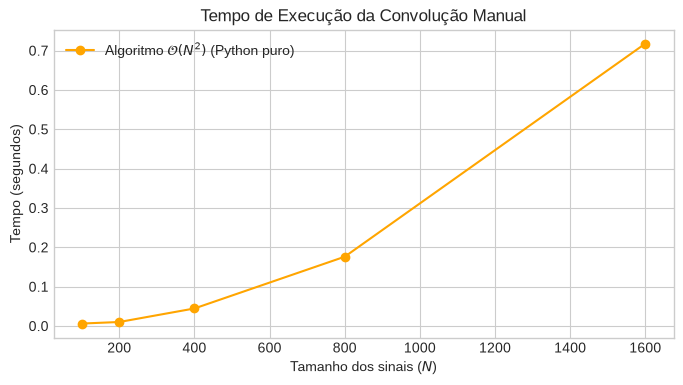

Nota-se o crescimento quadrático da curva de tempo.


In [7]:
tamanhos = [100, 200, 400, 800, 1600]
tempos_naive = []

for size in tamanhos:
    # Gera sinais aleatórios do tamanho especificado
    x_teste = np.random.rand(size)
    h_teste = np.random.rand(size)
    
    inicio = time.time()
    _ = minha_convolucao(x_teste, h_teste)
    fim = time.time()
    
    tempos_naive.append(fim - inicio)

plt.figure(figsize=(8, 4))
plt.plot(tamanhos, tempos_naive, 'o-', color='orange', label='Algoritmo $\mathcal{O}(N^2)$ (Python puro)')
plt.title('Tempo de Execução da Convolução Manual')
plt.xlabel('Tamanho dos sinais ($N$)')
plt.ylabel('Tempo (segundos)')
plt.legend()
plt.grid(True)
plt.show()

print("Nota-se o crescimento quadrático da curva de tempo.")

## 4. Aceleração de Código (Numba e CuPy)
Como visto, a convolução implementada em Python puro é lenta para arrays grandes devido ao *overhead* de interpretação de loops do Python.

### 4.1 Acelerando com Numba (JIT)
O **Numba** converte código Python/NumPy em código de máquina rápido (LLVM) usando o decorador `@jit`. Ele é ideal para acelerar laços `for` intensos.

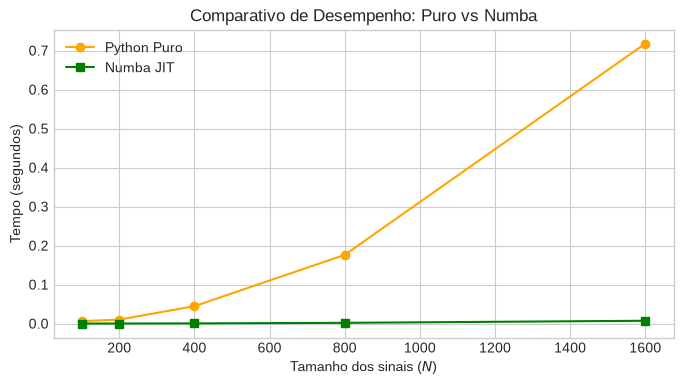

In [8]:
# O decorador @jit(nopython=True) força a compilação total sem depender do interpretador Python
@jit(nopython=True)
def convolucao_numba(x, h):
    Nx = len(x)
    Nh = len(h)
    Ny = Nx + Nh - 1
    y = np.zeros(Ny)
    for n in range(Ny):
        for k in range(Nx):
            if (n - k) >= 0 and (n - k) < Nh:
                y[n] += x[k] * h[n - k]
    return y

# Compilação no primeiro uso (warm-up)
_ = convolucao_numba(np.array([1.0]), np.array([1.0]))

tempos_numba = []
for size in tamanhos:
    x_teste = np.random.rand(size)
    h_teste = np.random.rand(size)
    
    inicio = time.time()
    _ = convolucao_numba(x_teste, h_teste)
    fim = time.time()
    tempos_numba.append(fim - inicio)

plt.figure(figsize=(8, 4))
plt.plot(tamanhos, tempos_naive, 'o-', color='orange', label='Python Puro')
plt.plot(tamanhos, tempos_numba, 's-', color='green', label='Numba JIT')
plt.title('Comparativo de Desempenho: Puro vs Numba')
plt.xlabel('Tamanho dos sinais ($N$)')
plt.ylabel('Tempo (segundos)')
plt.legend()
plt.grid(True)
plt.show()

### 4.2 Acelerando com CuPy (GPU)
O **CuPy** possui a sintaxe praticamente idêntica ao NumPy, mas executa as operações na placa de vídeo (GPU) da NVIDIA. 
Se você rodar isso no **Google Colab**, lembre-se de mudar o runtime para GPU.

In [ ]:
try:
    import cupy as cp
    gpu_disponivel = True
    print("CuPy importado com sucesso! GPU detectada.")
except ImportError:
    gpu_disponivel = False
    print("CuPy não instalado ou GPU incompatível. Pulando teste prático.")

if gpu_disponivel:
    tamanhos_gpu = [100, 200, 400, 800, 1600, 3200, 6400]
    tempos_cupy = []
    
    for size in tamanhos_gpu:
        x_gpu = cp.random.rand(size)
        h_gpu = cp.random.rand(size)
        
        # cp.cuda.Stream.null.synchronize() assegura medição correta do tempo da GPU
        cp.cuda.Stream.null.synchronize()
        inicio = time.time()
        # Usando a função nativa do CuPy que utiliza algoritmos otimizados na GPU
        _ = cp.convolve(x_gpu, h_gpu, mode='full')
        cp.cuda.Stream.null.synchronize()
        fim = time.time()
        
        tempos_cupy.append(fim - inicio)
        
    plt.figure(figsize=(8, 4))
    plt.plot(tamanhos_gpu, tempos_cupy, '^-', color='red', label='CuPy (GPU)')
    plt.title('Tempo de Execução - GPU (CuPy)')
    plt.xlabel('Tamanho dos sinais ($N$)')
    plt.ylabel('Tempo (segundos)')
    plt.legend()
    plt.grid(True)
    plt.show()

## 5. Roteiro para o Relatório (Sugestão)
- **Introdução:** Defina sinais discretos e a operação de convolução. Comente sobre o objetivo prático.
- **Desenvolvimento:** Explique as ferramentas utilizadas (`numpy`, `matplotlib`). Mostre a lógica por trás do algoritmo de loop duplo que você implementou e cite a notação Big-O ($\mathcal{O}(N^2)$).
- **Resultados:** Adicione os gráficos de execução de tempo que geramos aqui. Compare o tempo do Python puro com o do Numba e discuta os ganhos de performance.
- **Conclusão:** Finalize citando como é importante evitar laços `for` puros em Python para cálculos pesados e como o Numba ou as funções otimizadas (como FFT no `np.convolve` ou aceleração paralela na GPU com CuPy) resolvem esse gargalo de forma elegante.